Loading... the Dataset.

In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/Admin/Downloads/Clean_Dataset.csv/Clean_Dataset.csv')
print(df.head(10))
print('\nShape of the Dataset: ', df.shape)

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   
5           5   Vistara   UK-945       Delhi        Morning  zero   
6           6   Vistara   UK-927       Delhi        Morning  zero   
7           7   Vistara   UK-951       Delhi      Afternoon  zero   
8           8  GO_FIRST   G8-334       Delhi  Early_Morning  zero   
9           9  GO_FIRST   G8-336       Delhi      Afternoon  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning     

There are total 12 Columns and more than 300000 Rows

Dropping the extra index or column (Unnamed: 0)

In [2]:
df = df.drop(columns=['Unnamed: 0'])

Checking the missing values in the dataset (if exist any).

In [3]:
print(df.isnull().sum())

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


Well! No missing values exist!

Let's check the duplicated Rows (if there's any).

In [4]:
print(df.duplicated().sum())

0


Well! No duplicated columns exist!

Let's observe the statistical summary of the numerical columns in the dataset.

In [5]:
print(df.describe().T)

              count          mean           std      min      25%      50%  \
duration   300153.0     12.221021      7.191997     0.83     6.83    11.25   
days_left  300153.0     26.004751     13.561004     1.00    15.00    26.00   
price      300153.0  20889.660523  22697.767366  1105.00  4783.00  7425.00   

                75%        max  
duration      16.17      49.83  
days_left     38.00      49.00  
price      42521.00  123071.00  


Look at the correlations between numerical features in the dataset.

In [6]:
print(df.corr(numeric_only=True))

           duration  days_left     price
duration   1.000000  -0.039157  0.204222
days_left -0.039157   1.000000 -0.091949
price      0.204222  -0.091949  1.000000


No extreme correlation exist! Let's visualize the correlation for batter understanding.

<Axes: >

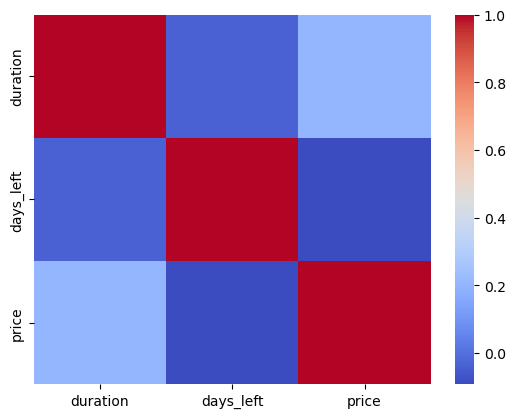

In [7]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')

```

Does ticket price vary by Airline?

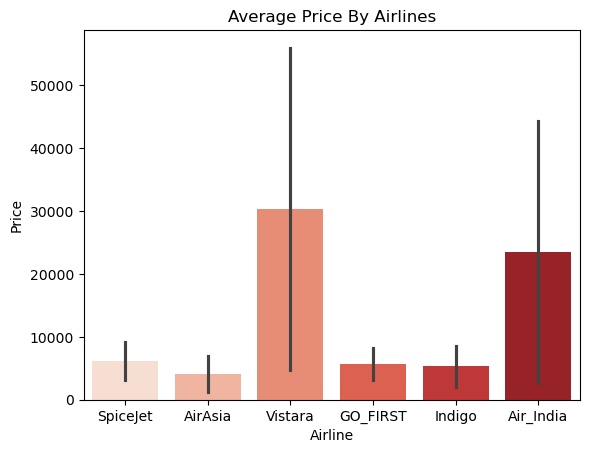

In [8]:
import matplotlib.pyplot as plt

sns.barplot(data=df,
            x='airline', 
            y='price', 
            hue='airline', 
            errorbar='sd', 
            palette='Reds',
            legend=False)
plt.xlabel('Airline')
plt.ylabel('Price')
plt.title('Average Price By Airlines')
plt.show()

Vistara has the highest average ticket price (around ₹30,000+).

Air India is second-highest (around ₹23,000).

AirAsia is the cheapest on average (under ₹5,000).

Go First, Indigo, and SpiceJet are all in the mid-lower range (~₹5,000–₹6,500).

```

How does price change when tickets are booked 1–2 days before departure?

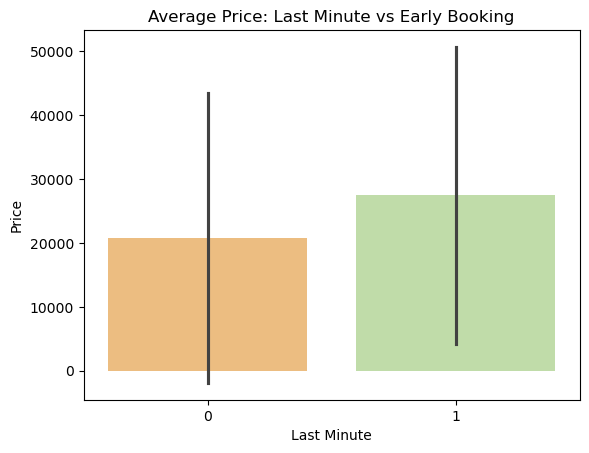

In [9]:
df['last_minute'] = df['days_left'].apply(lambda x : 1 if x <= 2 else 0)

sns.barplot(data=df,
            x='last_minute',
            y='price',
            hue='last_minute',
            errorbar='sd',
            palette='Spectral',
            legend=False)
plt.xlabel('Last Minute')
plt.ylabel('Price')
plt.title('Average Price: Last Minute vs Early Booking')
plt.show()

Last-minute bookings (1) tend to have a higher average ticket price than early bookings (0).

Specifically, the bar for 1 is taller, meaning people who booked late paid more on average.

The error bars (black lines) are quite long for both groups — this means there’s a lot of variation in ticket prices in each category. So while the average is higher for last-minute, there are still some cheap last-minute tickets and some expensive early bookings.
```

Does ticket price change based on Departure and Arrival times?

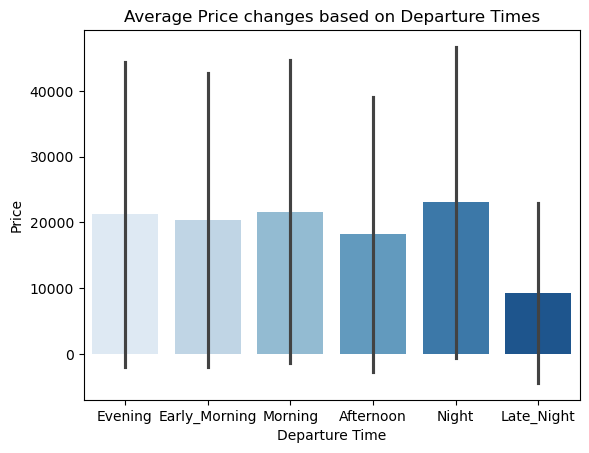

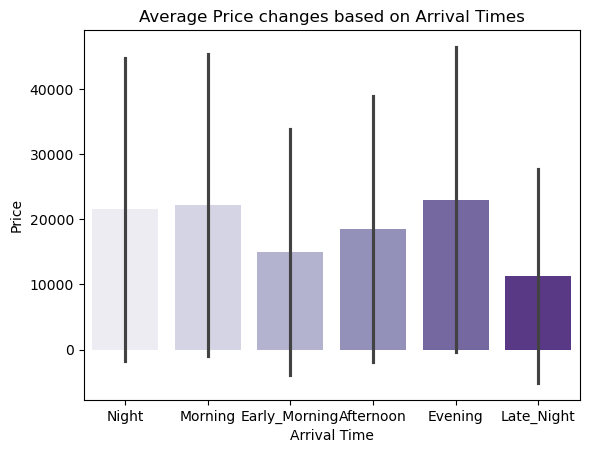

In [10]:
sns.barplot(data=df,
            x='departure_time',
            y='price',
            hue='departure_time',
            errorbar='sd',
            palette='Blues',
            legend=False)
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.title('Average Price changes based on Departure Times')
plt.show()

sns.barplot(data=df,
            x='arrival_time',
            y='price',
            hue='arrival_time',
            errorbar='sd',
            palette='Purples',
            legend=False)
plt.xlabel('Arrival Time')
plt.ylabel('Price')
plt.title('Average Price changes based on Arrival Times')
plt.show()

**Departure_Time average prices:**

Flights departing at Night have the highest average price (~23,062).

Late_Night departures are the cheapest by far (~9,295), possibly due to low demand or less convenience.

Morning, Evening, and Early_Morning departures have moderately high prices (~20,000 - 21,600).

Afternoon departures are somewhat cheaper (~18,179) than morning/evening.

This suggests that departure time affects ticket price, with late night flights cheapest and night/morning flights more expensive.


.....

.....


**Arrival_Time average prices:**

Flights arriving in the Evening have the highest average price (~23,044).

Morning and Night arrivals are also quite expensive (~21,500 - 22,200).

Late_Night and Early_Morning arrivals are cheapest (~11,285 and ~14,993).

Afternoon arrivals have moderate prices (~18,495).

This suggests arrival time also impacts price — flights arriving during early or late night tend to be cheaper, while those arriving during more convenient times (morning, evening) cost more.

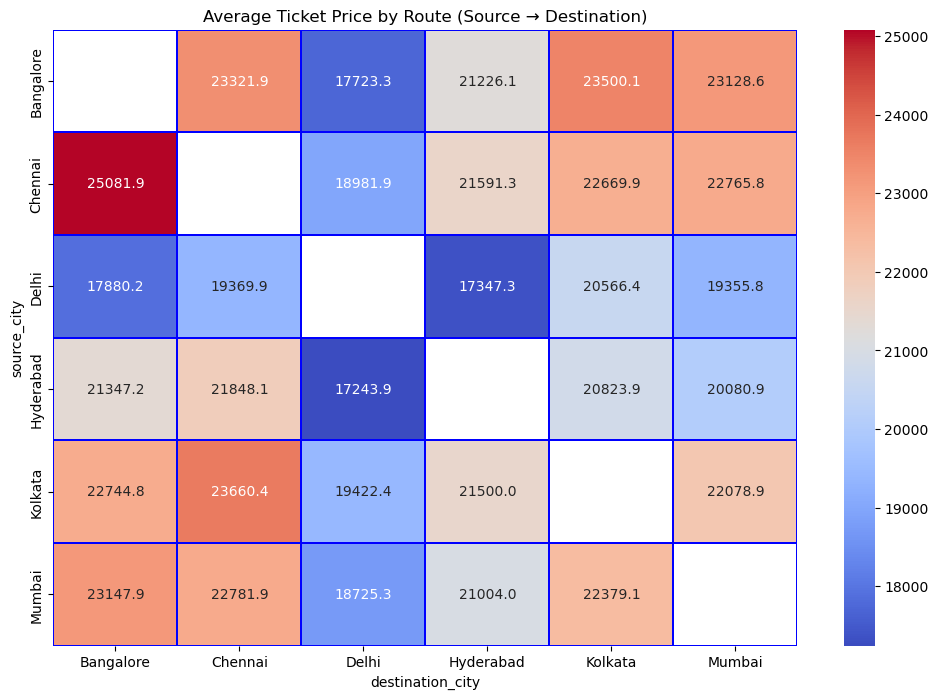

In [14]:
pivot = df.pivot_table(index='source_city', columns='destination_city', values='price', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.1, linecolor='blue')
plt.title('Average Ticket Price by Route (Source → Destination)')
plt.show()

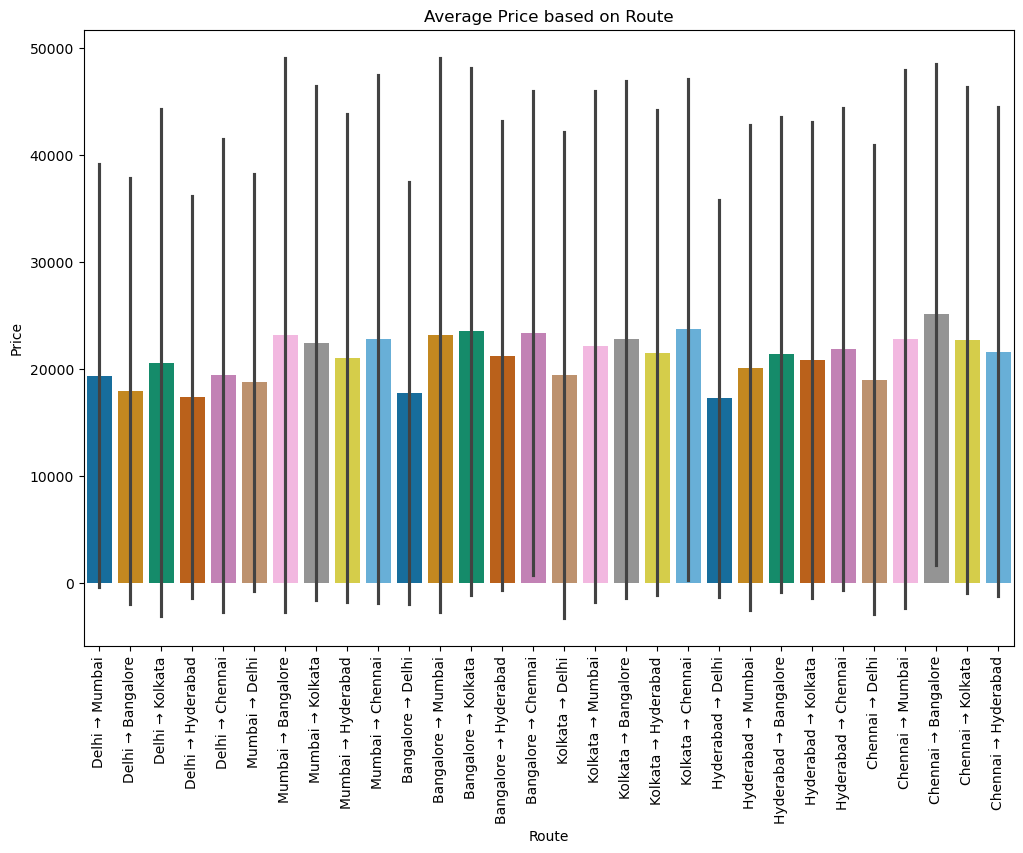

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['route'] = df['source_city'] + " → " + df['destination_city']
plt.figure(figsize=(12, 8))
sns.barplot(data=df, 
            x='route', 
            y='price', 
            hue='route', 
            errorbar='sd', 
            palette='colorblind', 
            legend=False)
plt.xlabel('Route')
plt.ylabel('Price')
plt.title('Average Price based on Route')
plt.xticks(rotation=90)
plt.show()

The highest average price in this matrix is from Bangalore → Delhi (about 78,177). This route is significantly more expensive than others.

Routes like Chennai → Delhi and Kolkata → Delhi are relatively cheaper (~4,545 and ~1,040 respectively).

Some routes have fairly similar prices, for example, flights from Mumbai to Chennai (~23,148) and Mumbai to Bangalore (~22,079) are close in price.

Most prices are in the range of roughly 15,000 to 25,000 units, except for some outliers like Bangalore → Delhi.

The diagonal is NaN because you don’t fly from a city to itself.


```

How does ticket price differ between Economy and Business class?

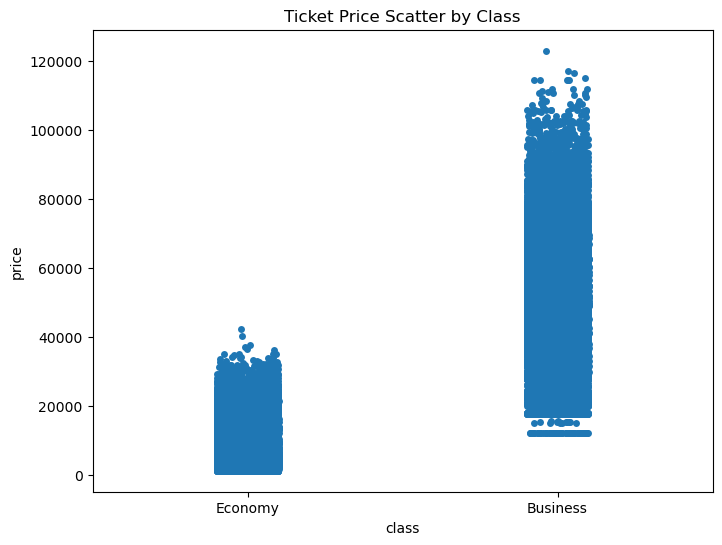

In [16]:
plt.figure(figsize=(8,6))
sns.stripplot(x='class', y='price', data=df)
plt.title('Ticket Price Scatter by Class')
plt.show()

**Average Ticket Prices by Class:**

Business Class: ~52,540

Economy Class: ~6,572

Business class tickets are, on average, about 8 times more expensive than Economy class tickets.

This large price gap reflects the premium services, comfort, and exclusivity associated with Business class compared to Economy.

In [17]:
df = pd.read_csv('C:/Users/Admin/Downloads/Clean_Dataset.csv/Clean_Dataset.csv')

df = df.drop(columns=['Unnamed: 0', 'flight'])
df['last_minute'] = df['days_left'].apply(lambda x : 1 if x <= 2 else 0)
df['route'] = df['source_city'] + " → " + df['destination_city']

df = pd.get_dummies(df, columns=['airline',
                             'source_city', 
                             'departure_time', 
                             'stops', 
                             'arrival_time', 
                             'destination_city',
                             'route',
                             'class'], dtype=int)
df.head(8)

,duration,days_left,price,last_minute,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,route_Kolkata → Delhi,route_Kolkata → Hyderabad,route_Kolkata → Mumbai,route_Mumbai → Bangalore,route_Mumbai → Chennai,route_Mumbai → Delhi,route_Mumbai → Hyderabad,route_Mumbai → Kolkata,class_Business,class_Economy
0,2.17,1,5953,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,2.33,1,5953,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,2.17,1,5956,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2.25,1,5955,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,2.33,1,5955,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
5,2.33,1,5955,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
6,2.08,1,6060,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
7,2.17,1,6060,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


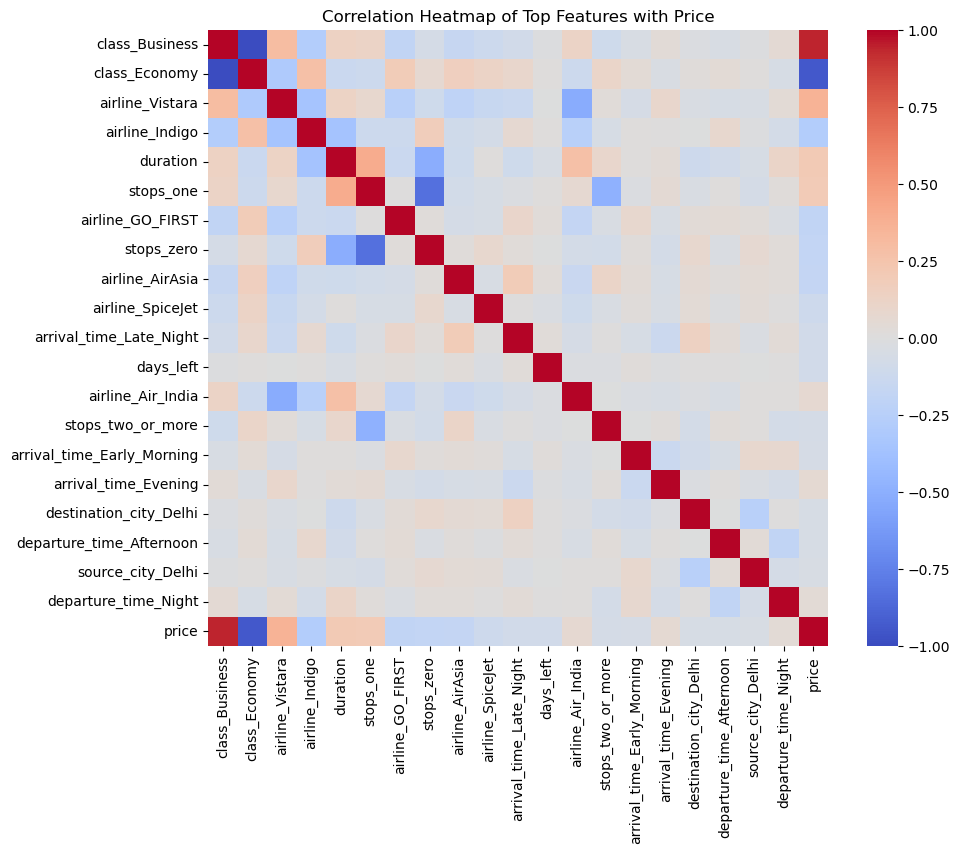

In [22]:
high_correlated_columns = df.corr()['price'].drop('price')
top_cols = high_correlated_columns.abs().sort_values(ascending=False).head(20).index.tolist()
selected_cols = top_cols + ['price']
corr_mat = df[selected_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Top Features with Price')
plt.show()

Strong correlations with price
class_Business → +0.94 → Business class tickets are much more expensive than average.

class_Economy → -0.94 → Economy class tickets are much cheaper than average.

These two are perfectly negatively correlated with each other (-1.00) because a ticket can only be one class.

Moderate correlations with price
airline_Vistara → +0.36 → Vistara flights tend to have higher prices.

duration → +0.20 → Longer flights tend to be more expensive.

stops_one → +0.20 → Flights with one stop tend to cost more than direct flights.

airline_Indigo → -0.28 → Indigo flights are generally cheaper.

airline_GO_FIRST → -0.19, stops_zero → -0.19 → GO FIRST and non-stop flights trend cheaper.

airline_AirAsia → -0.18 → AirAsia flights are generally lower-priced.

Weak correlations with price
Most other features (arrival time, departure time, source/destination city) have correlations between -0.1 and +0.1, meaning their effect on price is small in comparison.